# Phase 2a: CWRU Vibration Data and Feature Exploration

Explore the CWRU Bearing Dataset: raw vibration signals, frequency spectra,
and extracted degradation features across fault severities. Select the primary
feature for the adaptive drift model.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
})

# Colorblind-friendly palette for degradation phases
COLORS = {'healthy': '#4477AA', 'mild': '#66CCEE', 'moderate': '#CCBB44', 'severe': '#EE6677'}

## 2.1 Download CWRU Data

Download the minimal subset: normal baseline plus inner race faults at 0 HP.

In [2]:
from src.download_cwru import download_cwru_data

downloaded = download_cwru_data(
    output_dir='../data/raw',
    subset='inner_race',
    load_hp=0
)
print(f'\nAvailable files: {list(downloaded.keys())}')

  Skipping normal_0hp (already exists)
  Skipping ir_007_0hp (already exists)
  Skipping ir_014_0hp (already exists)
  Skipping ir_021_0hp (already exists)
Downloaded 4/4 files.

Available files: ['normal_0hp', 'ir_007_0hp', 'ir_014_0hp', 'ir_021_0hp']


## 2.2 Raw Vibration Signals

Compare time-domain vibration signatures across fault severities.

In [3]:
from src.feature_extraction import load_cwru_signal, BearingOEMParams

sr = 12000.0
rpm = 1797.0
shaft_freq = rpm / 60.0

files = {
    'healthy': '../data/raw/normal_0hp.mat',
    'mild': '../data/raw/ir_007_0hp.mat',
    'moderate': '../data/raw/ir_014_0hp.mat',
    'severe': '../data/raw/ir_021_0hp.mat',
}

signals = {}
for label, path in files.items():
    from pathlib import Path as P
    if P(path).exists():
        signals[label] = load_cwru_signal(path)
        print(f'{label}: {len(signals[label])} samples ({len(signals[label])/sr:.2f} seconds)')

if not signals:
    print('No data files found. Run download_cwru.py first.')

healthy: 243938 samples (20.33 seconds)
mild: 121265 samples (10.11 seconds)
moderate: 121846 samples (10.15 seconds)
severe: 122136 samples (10.18 seconds)


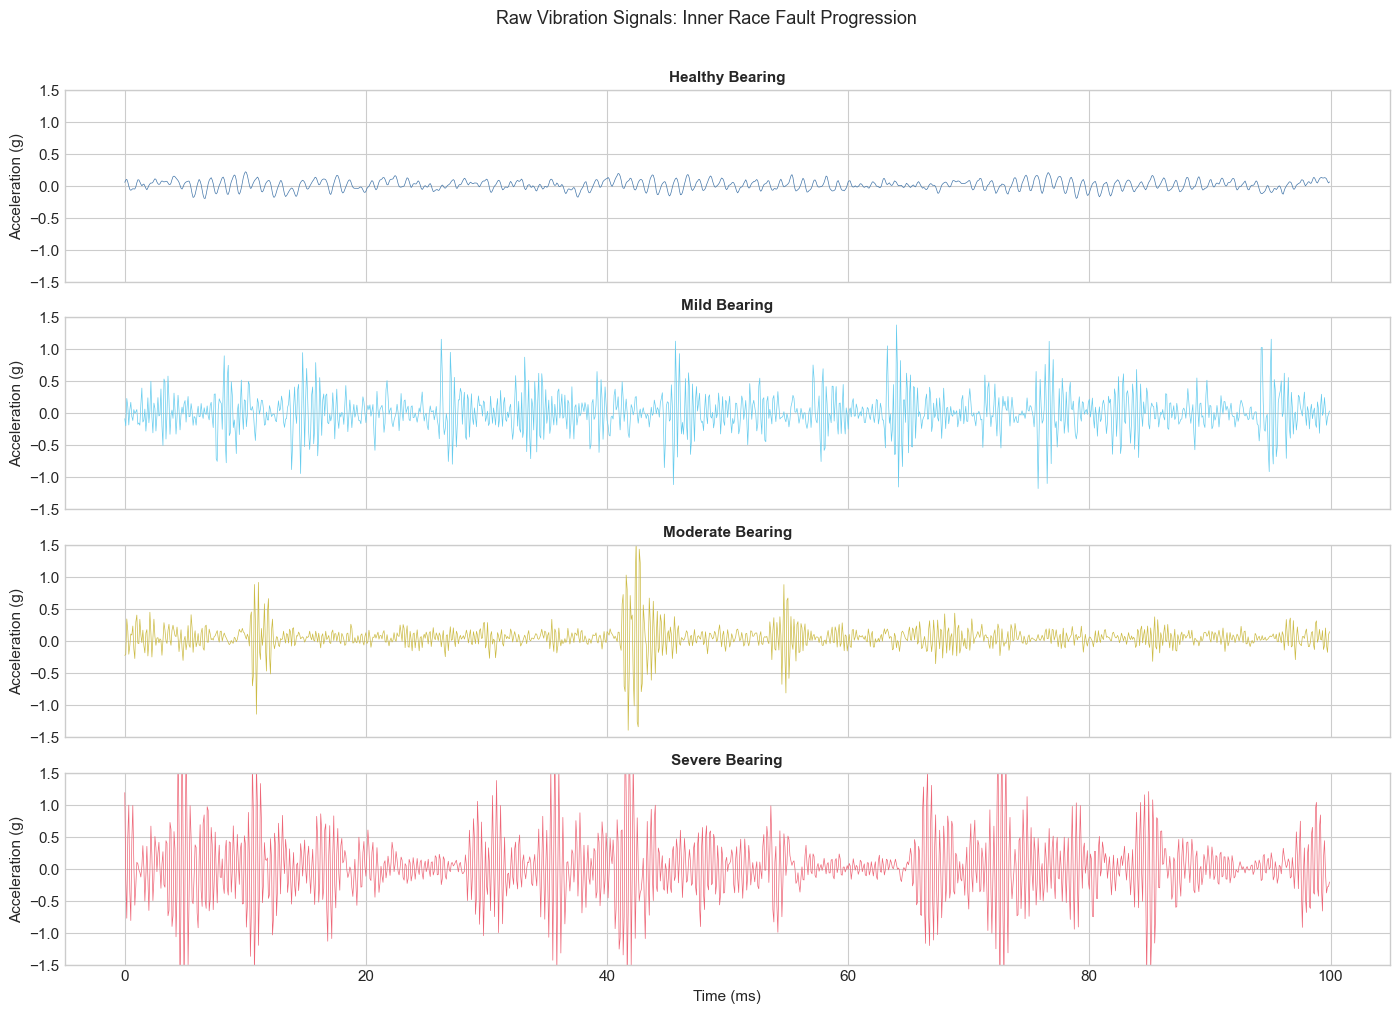

In [4]:
if signals:
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

    n_show = int(0.1 * sr)
    t = np.arange(n_show) / sr * 1000  # milliseconds

    for ax, (label, sig) in zip(axes, signals.items()):
        ax.plot(t, sig[:n_show], color=COLORS[label], linewidth=0.5)
        ax.set_ylabel('Acceleration (g)')
        ax.set_title(f'{label.capitalize()} Bearing', fontsize=11, fontweight='bold')
        ax.set_ylim(-1.5, 1.5)

    axes[-1].set_xlabel('Time (ms)')
    fig.suptitle('Raw Vibration Signals: Inner Race Fault Progression', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('../reports/figures/raw_vibration_signals.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2.3 Frequency Spectra

Show how defect frequency peaks emerge and grow with damage severity.

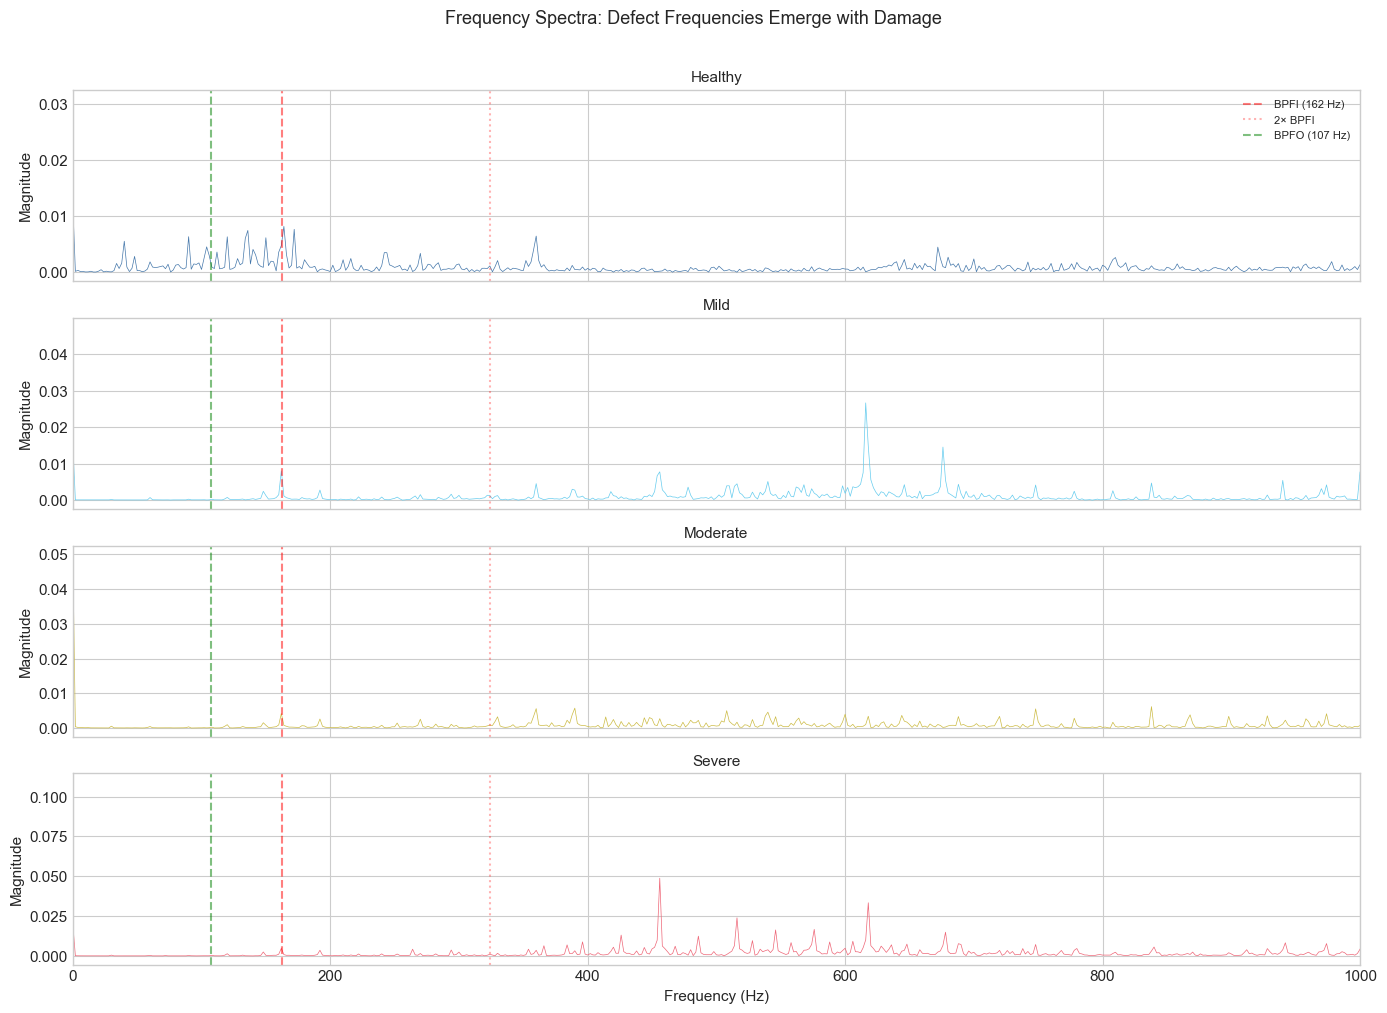

In [5]:
if signals:
    bpfi_hz = 5.4152 * shaft_freq
    bpfo_hz = 3.5848 * shaft_freq
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    
    for ax, (label, sig) in zip(axes, signals.items()):
        # Use first ~0.5 seconds for FFT
        n_fft = int(0.5 * sr)
        segment = sig[:n_fft]
        freqs = np.fft.rfftfreq(n_fft, 1/sr)
        fft_mag = np.abs(np.fft.rfft(segment)) / n_fft
        
        ax.plot(freqs, fft_mag, color=COLORS[label], linewidth=0.5)
        ax.axvline(bpfi_hz, color='red', linestyle='--', alpha=0.5, label=f'BPFI ({bpfi_hz:.0f} Hz)')
        ax.axvline(2 * bpfi_hz, color='red', linestyle=':', alpha=0.3, label='2× BPFI')
        ax.axvline(bpfo_hz, color='green', linestyle='--', alpha=0.5, label=f'BPFO ({bpfo_hz:.0f} Hz)')
        ax.set_ylabel('Magnitude')
        ax.set_title(f'{label.capitalize()}', fontsize=11)
        ax.set_xlim(0, 1000)
        if label == 'healthy':
            ax.legend(fontsize=8, loc='upper right')
    
    axes[-1].set_xlabel('Frequency (Hz)')
    fig.suptitle('Frequency Spectra: Defect Frequencies Emerge with Damage', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('../reports/figures/frequency_spectra.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2.4 Feature Extraction Across Degradation Trajectory

Build the synthetic degradation trajectory and plot features over time.

In [6]:
from src.feature_extraction import build_degradation_trajectory

# Set up bearing params for defect frequency features
bearing_params = BearingOEMParams(
    model='SKF 6205-2RS JEM',
    bore_mm=25.0,
    dynamic_load_rating_kn=14.8,
    static_load_rating_kn=7.8,
    life_exponent=3.0,
    bpfi=5.4152,
    bpfo=3.5848,
    ftf=0.39828,
    bsf=4.7135,
    max_speed_rpm=18000.0,
)

trajectory = build_degradation_trajectory(
    data_dir='../data/raw',
    fault_type='inner_race',
    load_hp=0,
    bearing_params=bearing_params,
)

print(f'Trajectory shape: {trajectory.shape}')
print(f'Columns: {list(trajectory.columns)}')
print(f'\nPhase distribution:')
print(trajectory['phase'].value_counts())

Trajectory shape: (502, 14)
Columns: ['rms', 'peak', 'crest_factor', 'kurtosis', 'skewness', 'peak_to_peak', 'bpfi_energy', 'bpfo_energy', 'bsf_energy', 'ftf_energy', 'broadband_energy', 'time_seconds', 'phase', 'time_index']

Phase distribution:
phase
healthy     202
mild        100
moderate    100
severe      100
Name: count, dtype: int64


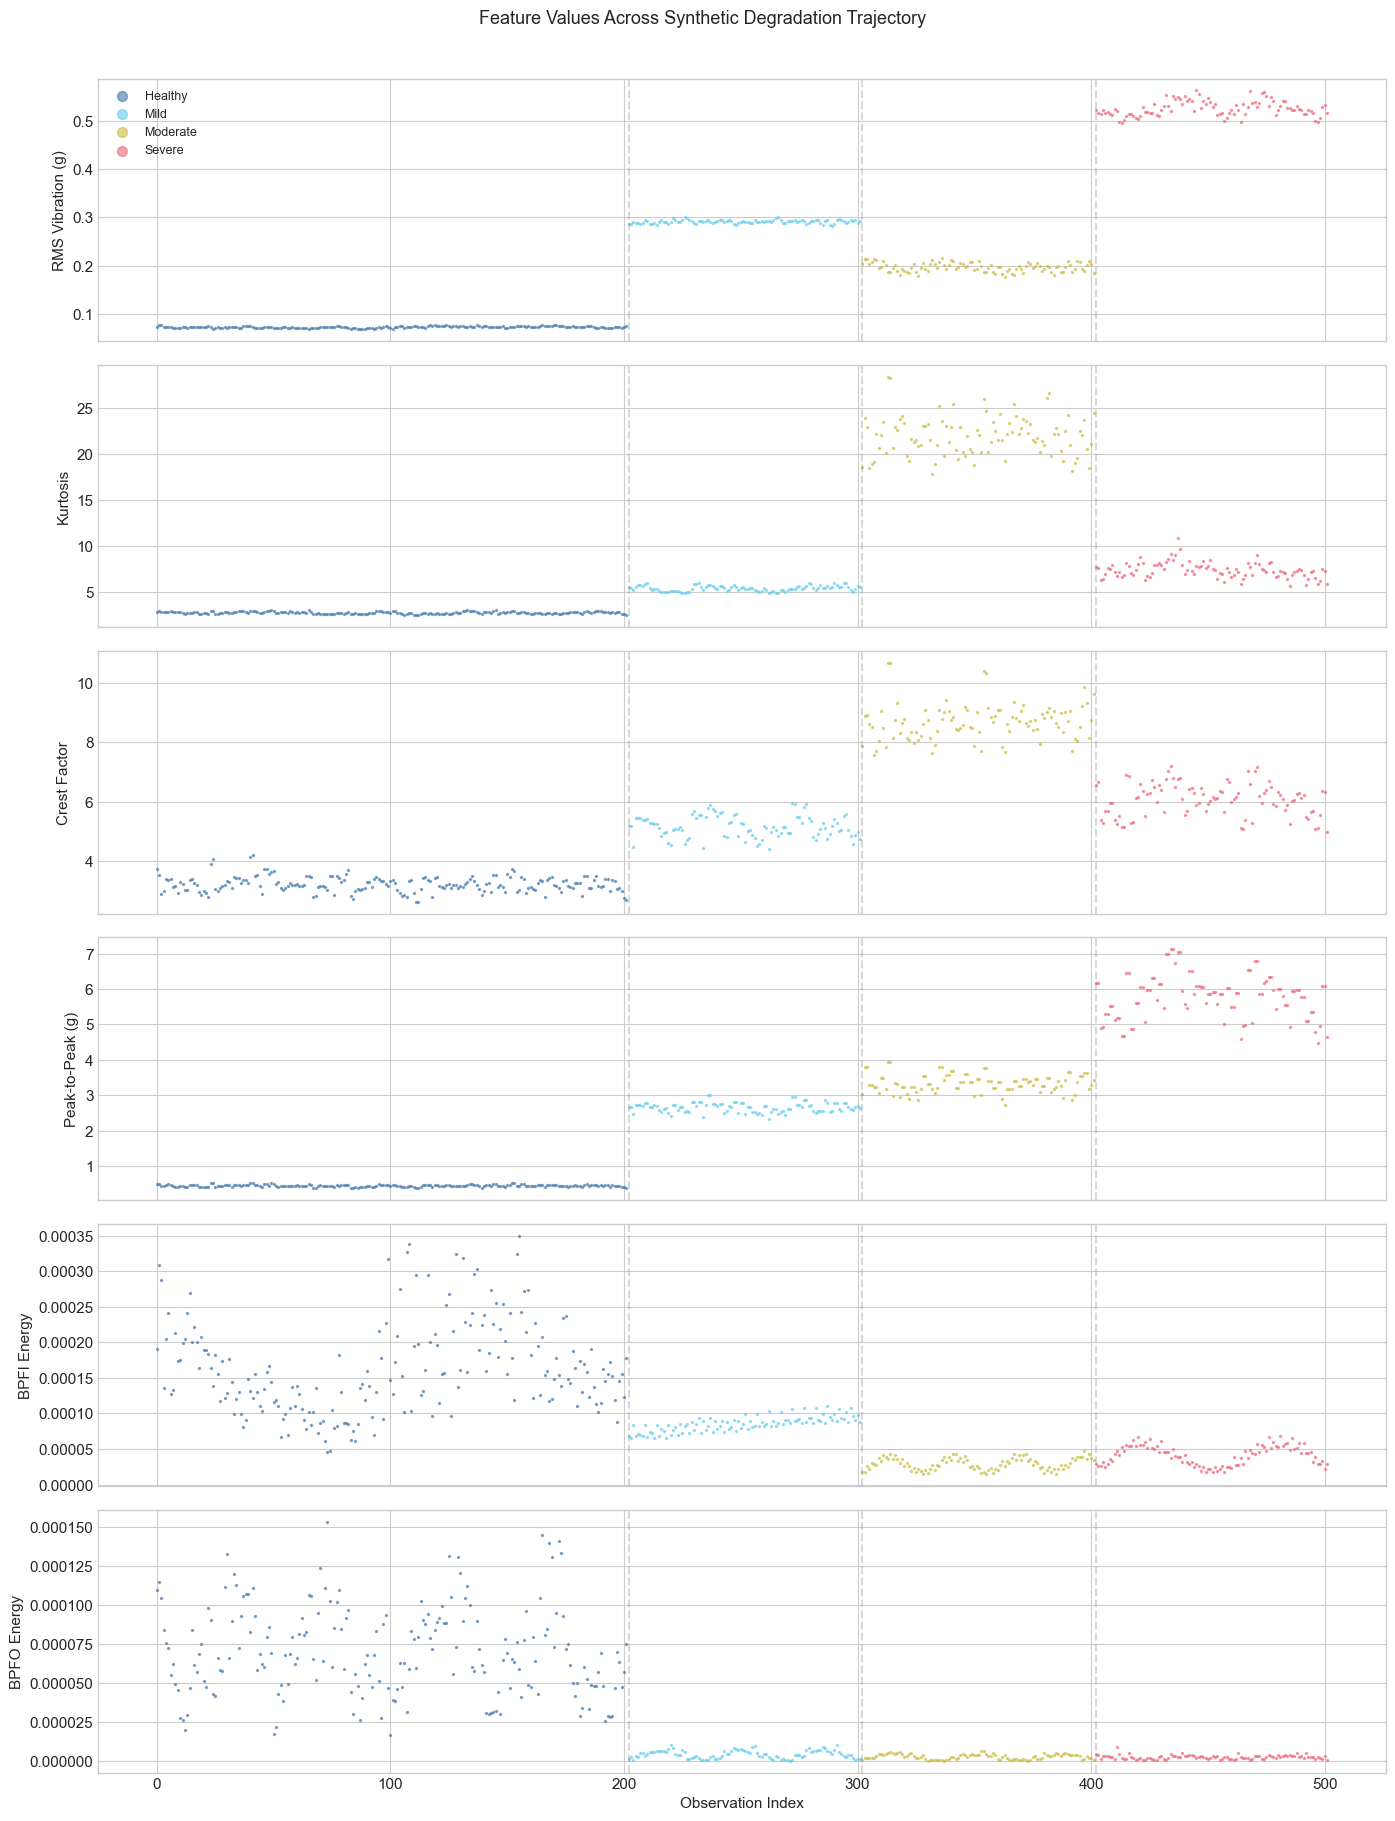

In [7]:
if len(trajectory) > 0:
    feature_cols = ['rms', 'kurtosis', 'crest_factor', 'peak_to_peak']
    if 'bpfi_energy' in trajectory.columns:
        feature_cols.extend(['bpfi_energy', 'bpfo_energy'])
    
    feature_labels = {
        'rms': 'RMS Vibration (g)',
        'kurtosis': 'Kurtosis',
        'crest_factor': 'Crest Factor',
        'peak_to_peak': 'Peak-to-Peak (g)',
        'bpfi_energy': 'BPFI Energy',
        'bpfo_energy': 'BPFO Energy',
    }
    
    n_features = len(feature_cols)
    fig, axes = plt.subplots(n_features, 1, figsize=(14, 3 * n_features), sharex=True)
    
    phase_colors = {'healthy': COLORS['healthy'], 'mild': COLORS['mild'],
                    'moderate': COLORS['moderate'], 'severe': COLORS['severe']}
    
    for ax, col in zip(axes, feature_cols):
        for phase in ['healthy', 'mild', 'moderate', 'severe']:
            mask = trajectory['phase'] == phase
            if mask.any():
                ax.scatter(trajectory.loc[mask, 'time_index'], trajectory.loc[mask, col],
                          s=2, alpha=0.6, color=phase_colors[phase], label=phase.capitalize())
        ax.set_ylabel(feature_labels.get(col, col))
        if col == feature_cols[0]:
            ax.legend(markerscale=5, fontsize=9, loc='upper left')
    
    # Mark phase boundaries
    phase_changes = trajectory.groupby('phase')['time_index'].agg(['min', 'max'])
    for ax in axes:
        for phase in phase_changes.index:
            if phase != 'healthy':
                ax.axvline(phase_changes.loc[phase, 'min'], color='gray',
                          linestyle='--', alpha=0.3)
    
    axes[-1].set_xlabel('Observation Index')
    fig.suptitle('Feature Values Across Synthetic Degradation Trajectory', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('../reports/figures/feature_trajectory.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2.5 Feature Discrimination Analysis

Which features best separate healthy from damaged states?

Feature discrimination (higher = better separation):
         feature  separation_ratio
    Peak-to-Peak          4.431150
    Crest Factor          4.031893
  Peak Amplitude          4.020687
     BPFO Energy          3.357592
      BSF Energy          3.276179
     BPFI Energy          2.738587
   RMS Vibration          2.468347
        Kurtosis          2.255057
Broadband Energy          1.794629
      FTF Energy          1.197467
        Skewness          1.013756


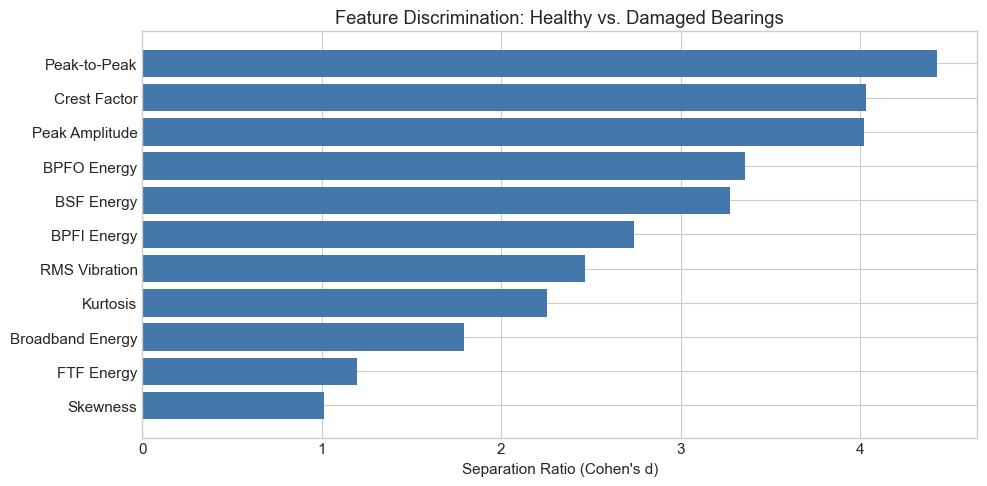

In [8]:
if len(trajectory) > 0:
    # Compute separation ratio for each feature
    # (mean_damaged - mean_healthy) / pooled_std
    numeric_cols = [c for c in trajectory.columns 
                    if c not in ['time_seconds', 'time_index', 'phase'] 
                    and trajectory[c].dtype in ['float64', 'float32']]
    
    healthy = trajectory[trajectory['phase'] == 'healthy']
    damaged = trajectory[trajectory['phase'].isin(['moderate', 'severe'])]
    
    feature_labels = {
        'rms': 'RMS Vibration', 'kurtosis': 'Kurtosis', 'crest_factor': 'Crest Factor',
        'peak_to_peak': 'Peak-to-Peak', 'skewness': 'Skewness',
        'bpfi_energy': 'BPFI Energy', 'bpfo_energy': 'BPFO Energy',
        'bsf_energy': 'BSF Energy', 'ftf_energy': 'FTF Energy',
        'broadband_energy': 'Broadband Energy', 'peak': 'Peak Amplitude',
    }
    
    separations = {}
    for col in numeric_cols:
        h_mean = healthy[col].mean()
        d_mean = damaged[col].mean()
        pooled_std = np.sqrt((healthy[col].var() + damaged[col].var()) / 2)
        if pooled_std > 1e-10:
            separations[col] = abs(d_mean - h_mean) / pooled_std
    
    sep_df = pd.DataFrame([
        {'feature': feature_labels.get(k, k), 'separation_ratio': v}
        for k, v in sorted(separations.items(), key=lambda x: -x[1])
    ])
    
    print('Feature discrimination (higher = better separation):')
    print(sep_df.to_string(index=False))
    
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(sep_df['feature'], sep_df['separation_ratio'], color='#4477AA')
    ax.set_xlabel("Separation Ratio (Cohen's d)")
    ax.set_title('Feature Discrimination: Healthy vs. Damaged Bearings')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('../reports/figures/feature_discrimination.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2.6 Save Processed Features

Save the extracted features for use in the model comparison notebook.

In [9]:
if len(trajectory) > 0:
    trajectory.to_csv('../data/processed/inner_race_trajectory.csv', index=False)
    print(f'Saved {len(trajectory)} rows to data/processed/inner_race_trajectory.csv')

Saved 502 rows to data/processed/inner_race_trajectory.csv


## Key Takeaways

1. **Kurtosis** is typically the strongest early indicator — it responds to impulsive
   spalling impacts before RMS levels rise significantly.
2. **Defect frequency energy** (BPFI for inner race faults) provides fault-type specificity.
3. **RMS** is a reliable overall degradation indicator but responds later than kurtosis.
4. The transition from mild to moderate damage shows the clearest feature changes —
   this is the regime transition the adaptive model needs to detect.